# 2D Structure Function (space,time)/ CROCO Data

This example will guide you through each step necessary to compute scalar-based structure functions from a 2D CROCO data (space,time).

$\textbf{General procedure}:$


1 -  Load a croco dataset, the dataset can be accessed https://doi.org/10.1175/JPO-D-18-0029.1

2 -  Format dataset to match pyturbo_sf inputs

3 -  Calculate second-order 2D scalar structure function as a function of separation distances (space and time)

4 -  Plot the 2D SF with errors and number of bootstraps

5 -  Evaluate and plot the time uncertainty 

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm
import matplotlib.ticker as ticker
import pyturbo_sf as psf
import pyproj
import numpy as np
linewidth = 2
fontsize = 12
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['xtick.minor.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['ytick.minor.width'] = 2
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['savefig.dpi'] = 150
plt.rc('font', family='serif')
import gc

# Load the CROCO Dataset

In [2]:
path_data = '/home/aayouche/Downloads/'
idt = 10
dsh = xr.open_dataset(path_data+'/'+'surface.nc')
dsg = xr.open_dataset(path_data+'/'+'GOM_150_grd.nc')

lon = dsg.lon_rho
lat = dsg.lat_rho

lon_center = np.nanmin(lon)
utm_zone = int(1 + (lon_center + 180.0) / 6.0)

# Create the projection
proj = pyproj.Proj(proj='utm', zone=utm_zone, ellps='WGS84', datum='WGS84')

x, y = proj(lon.values, lat.values) 



u = np.array(dsh.u.isel(s_rho=0,xi_u=10))

T,Y = np.meshgrid(dsh.ocean_time.values - dsh.ocean_time.values[0],y[:,10],indexing='ij')
gc.collect()

70

In [3]:
dsh

<xarray.Dataset> Size: 24GB
Dimensions:     (time: 763, eta_rho: 1538, xi_rho: 1026, s_rho: 1, xi_u: 1025,
                 eta_v: 1537)
Dimensions without coordinates: time, eta_rho, xi_rho, s_rho, xi_u, eta_v
Data variables:
    ocean_time  (time) float64 6kB 3.383e+07 3.384e+07 ... 3.657e+07 3.658e+07
    zeta        (time, eta_rho, xi_rho) float32 5GB ...
    u           (time, s_rho, eta_rho, xi_u) float32 5GB ...
    v           (time, s_rho, eta_v, xi_rho) float32 5GB ...
    temp        (time, s_rho, eta_rho, xi_rho) float32 5GB ...
    salt        (time, s_rho, eta_rho, xi_rho) float32 5GB ...
Attributes: (12/33)
    type:                      ROMS history file
    title:                     Nothern part of GOM, 500 meter model nested in...
    grid_file:                 GOM_150_grd.000.nc
    init_file:                 GOM_150_ini.000.nc
    ntimes:                    100000000
    ndtfast:                   57
    ...                        ...
    Zob_units:                 meter
    SRCS:                      KRNSRC main.F step2D_FB.F read_inp.F read_sta_...
    CPPS:                      <cppdefs.h> ATLANTIC SOLVE3D UV_ADV UV_COR SAL...
    nc_format:                 netCDF-4, zlib-compressed
    history:                   Sat May  7 14:02:43 2016: ncrcat -d s_rho,59 -...
    nco_openmp_thread_number:  1

# Format Dataset

In [4]:
# Create the xarray dataset
ds = xr.Dataset({
    'u': (['time', 'y'], u),


}, coords={
    'y': (['time','y'], Y),
    'time': (['time','y'], T)
})



# Make A quick plot

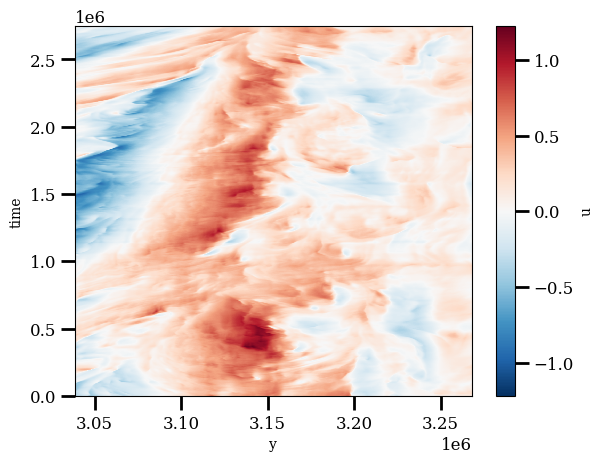

In [5]:
ds.u.plot()

# Define Keywords for CROCO

In [6]:
bins = {
    'time': np.logspace(np.log10(3600.), np.log10(2743200.0), 12),
    'y': np.logspace(np.log10(150.), np.log10(155.0e3), 12)
}
kwargs = dict(
    ds=ds,
    variables_names=["u"],
    order=2,
    fun='scalar',
    bins=bins,
    bootsize={'y': 96, 'time': 47},
    initial_nbootstrap=60,
    max_nbootstrap=420,
    step_nbootstrap=40,
    convergence_eps=0.1,
    n_jobs=-1,
    backend='loky',
    seed=42
)

# Calculation 2D (y,time) scalar sf $\delta^{2} u$

In [7]:
%%time

sf_result = psf.bin_sf_2d(**kwargs)

Found time dimension in ['time', 'y'], allowing flexible dimension names
Dimension 'time' is detected as a time dimension
Using bootsize: {'y': 96, 'time': 47}
Bootstrappable dimensions: ['time', 'y']
Two bootstrappable dimensions. Available spacings: [1, 2, 4, 8, 16]

STARTING BIN_SF WITH FUNCTION TYPE: scalar
Variables: ['u'], Order: 2
Using seed 42 for reproducible bootstrap sampling


INITIAL BOOTSTRAP PHASE
Processing spacing 1 with 12 bootstraps
Processing spacing 2 with 12 bootstraps
Processing spacing 4 with 12 bootstraps
Processing spacing 8 with 12 bootstraps
Processing spacing 16 with 12 bootstraps

CALCULATING BIN DENSITIES
Total points collected: 314847360
Bins with points: 112/121
Marked 9 bins as converged (low_density)
Marked 111 bins as converged (converged_eps)

STARTING ADAPTIVE CONVERGENCE LOOP

Iteration 1 - 1 unconverged bins
Grouped unconverged bins into 1 groups

Processing 1 bins with step size 40 in density quartile 0
  Bin (2,9) CONVERGED with std 0.020697
Al

In [8]:
sf_result

<xarray.Dataset> Size: 7kB
Dimensions:       (time: 11, y: 11, edge: 2)
Coordinates:
  * time          (time) float64 88B 4.867e+03 8.898e+03 ... 1.11e+06 2.029e+06
  * y             (y) float64 88B 205.6 386.5 726.3 ... 6.016e+04 1.131e+05
Dimensions without coordinates: edge
Data variables:
    sf            (time, y) float64 968B 0.0003787 0.0003637 ... 0.1855 0.1369
    std_error     (time, y) float64 968B 0.0003822 0.000282 ... 0.003363 0.00181
    ci_upper      (time, y) float64 968B nan nan nan nan nan ... nan nan nan nan
    ci_lower      (time, y) float64 968B nan nan nan nan nan ... nan nan nan nan
    nbootstraps   (time, y) int64 968B 60 60 60 60 60 60 ... 60 60 60 60 60 60
    density       (time, y) float32 484B 1.0 0.8776 ... 0.0001445 0.0001308
    point_counts  (time, y) int64 968B 159012 262272 463716 ... 2802240 4765320
    converged     (time, y) bool 121B True True True True ... True True True
    y_bins        (y, edge) float64 176B 150.0 281.9 ... 8.247e+04 1.55e+05
    time_bins     (time, edge) float64 176B 3.6e+03 6.581e+03 ... 2.743e+06
Attributes: (12/15)
    bin_type_x:                 logarithmic
    bin_type_y:                 logarithmic
    convergence_eps:            0.1
    max_nbootstrap:             420
    initial_nbootstrap:         60
    order:                      2
    ...                         ...
    bootstrappable_dimensions:  time,y
    time_dimensions:            time
    backend:                    loky
    confidence_level:           0.95
    weighting:                  volume_element
    bootstrap_se_method:        n_eff_correction

# Plot 2D SFs

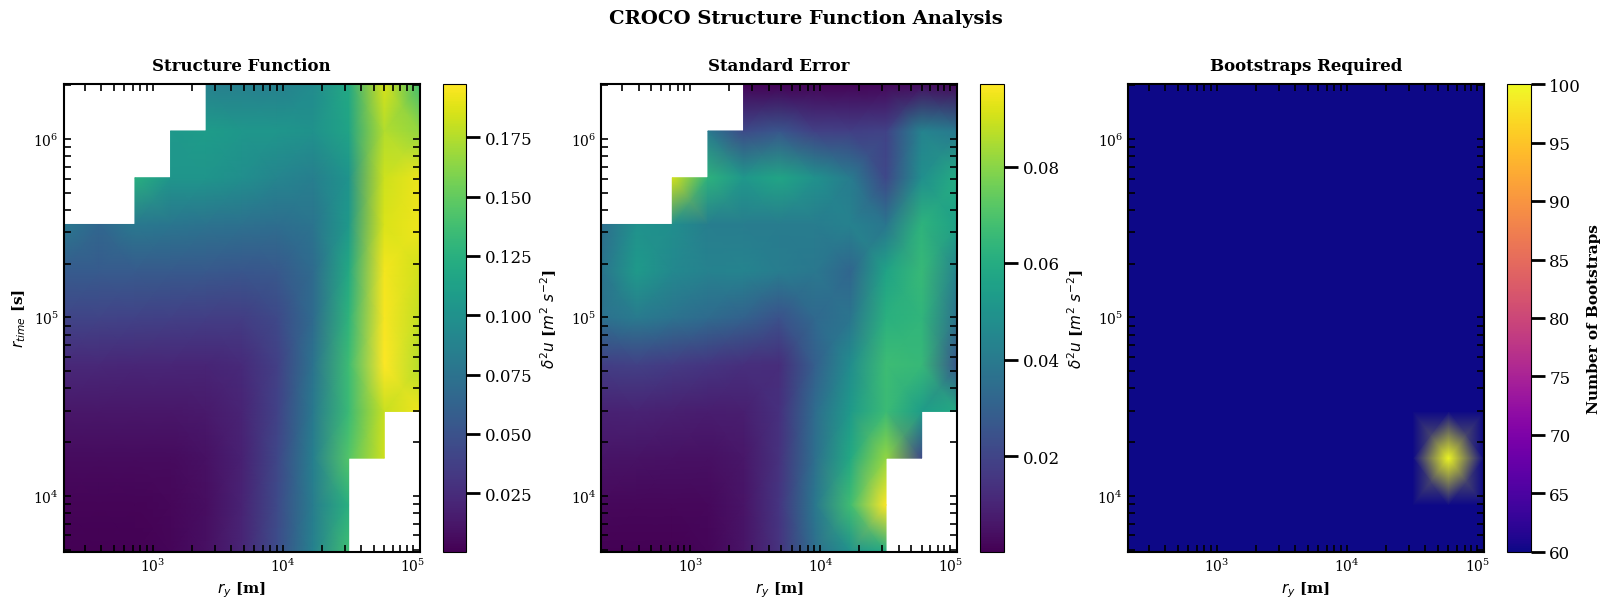

In [9]:
# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), constrained_layout=True)

# Common settings for all plots

plot_titles = ['Structure Function', 'Standard Error', 'Bootstraps Required']
cmaps = ['viridis', 'viridis', 'plasma']
labels = [r'$\delta^{2} u$ [$m^{2}~s^{-2}$]', r'$\delta^{2} u$ [$m^{2}~s^{-2}$]', 'Number of Bootstraps']

# Data to plot
data_to_plot = [sf_result.sf, sf_result.std_error, sf_result.nbootstraps]

for i, (ax, data, title, cmap, label) in enumerate(zip(axes, data_to_plot, plot_titles, cmaps, labels)):
    # Create the plot with specific shading for the first plot
    if i == 0:
        im = ax.pcolormesh(sf_result.y, sf_result.time, data, cmap=cmap, shading='gouraud')
    else:
        im = ax.pcolormesh(sf_result.y, sf_result.time, data, cmap=cmap, shading='gouraud')
    
    # Add colorbar with proper formatting
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(label, fontsize=11, fontweight='bold')
    
    # Set axis labels and title
    ax.set_xlabel(r'$r_y$ [m]', fontsize=11, fontweight='bold')
    if i == 0:
        ax.set_ylabel(r'$r_{time}$ [s]', fontsize=11, fontweight='bold')
    
    # Set log scales
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    # Add title
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    
    # Customize spines
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    
    # Customize tick parameters
    ax.tick_params(which='both', direction='in', width=1.2, length=5, 
                  labelsize=10, top=True, right=True)
    

    
    # Add scientific notation for axes
    ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
    ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# Add main title for the entire figure
fig.suptitle('CROCO Structure Function Analysis', fontsize=14, fontweight='bold', y=1.08)

plt.show()

# Check Stationnarity

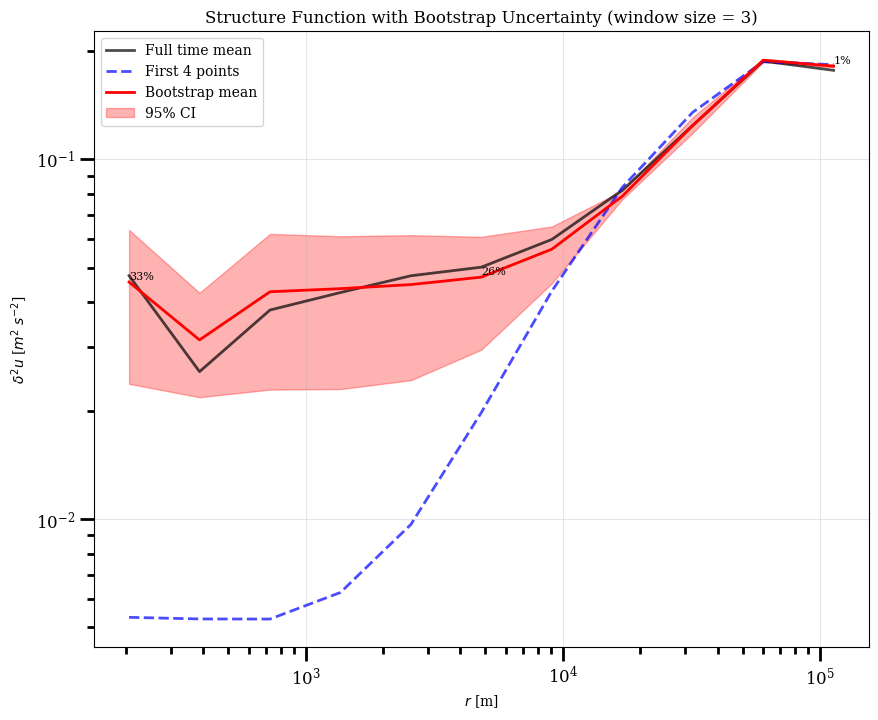

Relative uncertainties:
------------------------------
y = 2.06e+02: 32.8%
y = 7.26e+02: 33.1%
y = 4.82e+03: 25.5%
y = 3.20e+04: 3.8%
y = 1.13e+05: 0.6%


In [10]:
# Simple bootstrap approach for immediate use
import numpy as np
import matplotlib.pyplot as plt

# Quick bootstrap with sliding windows
window_size = 3
n_bootstrap = 5 # less than the number of possible windows
n_time = 11  # your time dimension size

# Create all possible windows
windows = []
for i in range(n_time - window_size + 1):
    windows.append(slice(i, i + window_size))
# Bootstrap by resampling windows
bootstrap_means = []
for _ in range(n_bootstrap):
    # Randomly sample windows with replacement
    sampled_windows = np.random.choice(len(windows), size=len(windows), replace=True)
    
    # Combine data from sampled windows
    combined_data = []
    for idx in sampled_windows:
        combined_data.append(sf_result.sf.isel(time=windows[idx]))
    
    # Calculate mean across all sampled windows
    bootstrap_mean = xr.concat(combined_data, dim='time').mean('time')
    bootstrap_means.append(bootstrap_mean)

# Convert to array for easier calculation
bootstrap_array = np.array([b.values for b in bootstrap_means])

# Calculate statistics
mean_sf = np.mean(bootstrap_array, axis=0)
std_sf = np.std(bootstrap_array, axis=0)
ci_lower = np.percentile(bootstrap_array, 2.5, axis=0)
ci_upper = np.percentile(bootstrap_array, 97.5, axis=0)

# Plot with uncertainty bands
plt.figure(figsize=(10, 8))

# Original full mean
plt.loglog(sf_result.y, sf_result.sf.mean('time'), 'k-', 
           linewidth=2, label='Full time mean', alpha=0.7)

# First window mean (as in your example)
plt.loglog(sf_result.y, sf_result.sf.isel(time=slice(0,4)).mean('time'), 
           'b--', linewidth=2, label='First 4 points', alpha=0.7)

# Bootstrap mean with confidence interval
plt.loglog(sf_result.y, mean_sf, 'r-', linewidth=2, label='Bootstrap mean')
plt.fill_between(sf_result.y.values, ci_lower, ci_upper, 
                 alpha=0.3, color='red', label='95% CI')

# Add relative uncertainty as text at a few points
y_vals = sf_result.y.values
for i in [0, len(y_vals)//2, -1]:
    rel_uncertainty = (std_sf[i] / mean_sf[i]) * 100
    plt.text(y_vals[i], mean_sf[i], f'{rel_uncertainty:.0f}%', 
             fontsize=8, ha='left', va='bottom')

plt.xlabel(r'$r$ [m]')
plt.ylabel(r'$\delta^{2} u$ [$m^{2}~s^{-2}$]')
plt.title(f'Structure Function with Bootstrap Uncertainty (window size = {window_size})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print uncertainty at different scales
print("Relative uncertainties:")
print("-" * 30)
for i in [0, len(y_vals)//4, len(y_vals)//2, 3*len(y_vals)//4, -1]:
    rel_unc = (std_sf[i] / mean_sf[i]) * 100
    print(f"y = {y_vals[i]:.2e}: {rel_unc:.1f}%")